# Lightweight-SRT: 核心流程演示
本 Notebook 用于展示重构后的架构中，从数据流加载、可视化到模型前向传播及蒸馏 Loss 计算的完整闭环。

In [17]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# 自动挂载项目根目录，确保可以 import src 下的模块
PROJECT_ROOT = os.path.dirname(os.path.abspath(""))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    sys.path.append(os.path.join(PROJECT_ROOT, 'src', 'student_model'))

print(f"[INFO] 项目根目录: {PROJECT_ROOT}")

[INFO] 项目根目录: E:\A-NJU\Lightweight-SRT


### 第一步：Dataset 数据流验证
验证封装好的 `StudentDataset` 是否能同步、准确地返回骨骼数据、教师 Logits 和真实标签。

In [18]:
from src.common.datasets.student_dataset import StudentDataset

# 配置路径 (重构后的新路径)
SPLIT_JSON = os.path.join(PROJECT_ROOT, 'data/WLASL2000/preprocess/nslt_2000.json')
SKELETON_DIR = os.path.join(PROJECT_ROOT, 'processed/skeletons')
LOGITS_DIR = os.path.join(PROJECT_ROOT, 'processed/logits')

# 实例化 Dataset (以 train 模式为例)
dataset = StudentDataset(
    split_json=SPLIT_JSON,
    skeleton_dir=SKELETON_DIR,
    logits_dir=LOGITS_DIR,
    subset='train',
    seq_len=64
)

print(f"[INFO] 数据集加载成功，样本总数: {len(dataset)}")

# 随机抽取一个样本
skeleton_t, logits_t, label_t, vid = dataset[0]

print("-" * 30)
print(f"视频 ID: {vid}")
print(f"骨骼点数据维度 (T, F): {skeleton_t.shape} -> [帧数, 关键点*坐标]")
print(f"教师 Logits 维度: {logits_t.shape}")
print(f"真实标签: {label_t.item()}")
print("-" * 30)

[INFO] 数据集加载成功，样本总数: 7436
------------------------------
视频 ID: 35544
骨骼点数据维度 (T, F): torch.Size([64, 63]) -> [帧数, 关键点*坐标]
教师 Logits 维度: torch.Size([2000])
真实标签: 1164
------------------------------


### 第二步：骨骼点提取质量可视化
通过可视化 MediaPipe 提取的 21 个手部关键点，验证数据清洗和补齐的效果。

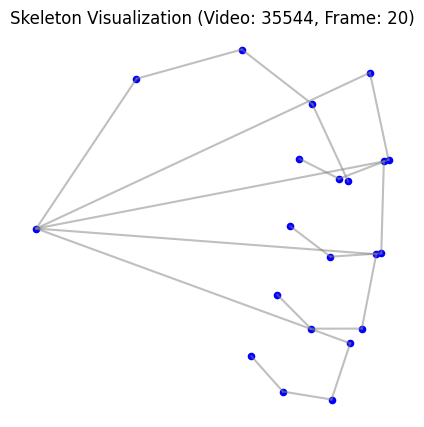

In [20]:
def plot_hand_skeleton(skeleton_tensor, frame_idx=0):
    # 将维度还原为 (T, V, C)
    data = skeleton_tensor.view(64, 21, 3).numpy()
    frame_data = data[frame_idx]

    x = frame_data[:, 0]
    y = frame_data[:, 1]

    plt.figure(figsize=(5, 5))
    plt.scatter(x, -y, c='blue', s=20)

    # 画连线
    connections = [
        (0,1), (1,2), (2,3), (3,4),
        (0,5), (5,6), (6,7), (7,8),
        (0,9), (9,10), (10,11), (11,12),
        (0,13), (13,14), (14,15), (15,16),
        (0,17), (17,18), (18,19), (19,20)
    ]

    for start, end in connections:
        plt.plot([x[start], x[end]], [-y[start], -y[end]], 'gray', alpha=0.5)

    plt.title(f"Skeleton Visualization (Video: {vid}, Frame: {frame_idx})")
    plt.axis('off')
    plt.show()

plot_hand_skeleton(skeleton_t, frame_idx=20)

### 第三步：ST-GCN 前向传播
验证轻量级 ST-GCN 模型的输入输出接口是否适配。

In [21]:
from src.student_model.architecture.st_gcn import Model

# 实例化 ST-GCN 模型
model = Model(
    in_channels=3,
    num_class=2000,
    graph_args={'layout': 'openpose', 'strategy': 'spatial'},
    edge_importance_weighting=True
)
model.train() # 设置为训练模式以开启梯度追踪

def to_stgcn_input(data):
    t, f = data.shape
    v = f // 3
    data = data.view(t, v, 3).permute(2, 0, 1).unsqueeze(-1).unsqueeze(0)
    return data

input_tensor = to_stgcn_input(skeleton_t)
print(f"[INFO] 输入模型 Tensor 维度: {input_tensor.shape}")

# 注意：此处移除了 with torch.no_grad()，因为后面要演示反向传播
output = model(input_tensor)

print(f"[INFO] 模型预测输出维度: {output.shape} -> [Batch, Classes]")

[INFO] 输入模型 Tensor 维度: torch.Size([1, 3, 64, 21, 1])
[INFO] 模型预测输出维度: torch.Size([1, 2000]) -> [Batch, Classes]


### 第四步：蒸馏 Loss 计算与反向传播
演示计算分类损失 (CE) 与 知识蒸馏损失 (KL-Div)，并验证梯度反传链路。

In [22]:
def calculate_loss(student_logits, teacher_logits, labels, alpha=0.5, temperature=4.0):
    loss_ce = F.cross_entropy(student_logits, labels)
    student_soft = F.log_softmax(student_logits / temperature, dim=1)
    teacher_soft = F.softmax(teacher_logits.unsqueeze(0) / temperature, dim=1)
    loss_kd = F.kl_div(student_soft, teacher_soft, reduction='batchmean') * (temperature ** 2)
    total_loss = (1 - alpha) * loss_ce + alpha * loss_kd
    return total_loss, loss_ce, loss_kd

loss, ce, kd = calculate_loss(output, logits_t, label_t.unsqueeze(0))
print(f"[INFO] 总损失: {loss.item():.4f}")

loss.backward() # 此时 forward 产生的计算图会允许反向传播
print("\n[SUCCESS] 反向传播成功完成！梯度已更新到模型参数中。")

[INFO] 总损失: 5.5870

[SUCCESS] 反向传播成功完成！梯度已更新到模型参数中。
